# Notebook 08 — Évaluation finale : comparaison des modèles et portefeuilles long-short

**Objectif de ce notebook :**
- **Partie A — Comparaison du R²_oos** : charger les résultats déjà sauvegardés par les 3
  modèles (régression linéaire, Elastic Net, LightGBM, Random Forest), les comparer statistiquement sur
  `train`/`validation`/`test` (chacun **pooled sur toutes les fenêtres**, voir notebooks
  04-06), diagnostiquer un éventuel sur-apprentissage, et regarder l'évolution du R²_oos test
  fenêtre par fenêtre
- **Partie B — Portefeuilles long-short par décile** : traduire les prédictions de chaque
  modèle en portefeuille investissable (achat du décile prédit le plus haut, vente à découvert
  du décile le plus bas), et évaluer leur performance avec des mesures financières standard
  (Sharpe, Sortino, drawdown maximum, significativité statistique...)
- **Partie C — Portefeuille combiné (ensemble)** : au lieu de choisir *un* modèle, combiner
  les prédictions de plusieurs d'entre eux (par défaut LightGBM + Random Forest) en une
  prédiction unique, pondérée soit à la main soit par une méthode d'estimation, puis en faire
  un portefeuille long-short évalué exactement comme les autres. Tout se règle dans
  `config.py`, section « Portefeuille COMBINÉ » ; la logique est dans `ensemble.py`.
- **Synthèse finale** : le modèle le plus précis statistiquement (`R²_oos`) est-il aussi celui
  qui dégage le meilleur portefeuille (`Sharpe`) ? Un bon `R²_oos` ne garantit pas
  automatiquement une bonne stratégie d'investissement — voir la synthèse en fin de notebook.

⚠️ **Pré-requis : avoir déjà exécuté les notebooks 04 à 07** (les 4 modèles), qui
produisent `outputs/resultats_*.parquet` et surtout `outputs/predictions_*.parquet` — **aucun
ré-entraînement, et aucun rechargement de modèle `.joblib`, n'est fait ici.**

ℹ️ **Comment ce notebook consomme les modèles.** Chaque modèle (04-07) a été ré-entraîné
plusieurs fois sur des fenêtres qui avancent dans le temps, et a déjà sauvegardé ses
**prédictions de test pooled** (une ligne par `permno`/`annee_mois`, toutes fenêtres mises
bout à bout) dans `outputs/predictions_*.parquet`. Ce notebook se contente donc de **charger
ces prédictions directement** — pas besoin de recharger un modèle ni de re-prédire quoi que
ce soit.

ℹ️ **Pourquoi regrouper la comparaison statistique et les portefeuilles dans un même
notebook ?** Ce sont les deux faces d'une même question — « quel modèle choisir au final ? »
— vue sous deux angles complémentaires (statistique, puis économique). Les regrouper permet
la synthèse finale ci-dessous, impossible à faire séparément.

ℹ️ **Ce notebook fait partie du pipeline automatique du notebook 00**
(`pipeline.py`, voir `GRAPHE_DEPENDANCES`) -- il se relance automatiquement dès que l'un des
4 modèles (ou `NB_DECILES`) change, en plus de pouvoir toujours être relancé à la main. Sa
partie B (section B.6) tague chaque modèle avec sa `cle_experience` (déjà écrite dans
`outputs/resultats_*.parquet` par 04/05/06/07, section 7), et **ajoute** (sans jamais rien
écraser, section B.8) ses mesures de portefeuille à
`outputs/historique_performance_portefeuilles.parquet` -- c'est ce qui permet au
**notebook 09** d'afficher, en plus du `R²_oos`, les mêmes mesures de portefeuille (Sharpe,
Sortino...) de **chaque** expérience du journal déjà évaluée par 08 (pas seulement la
dernière), directement dans ses tableaux de comparaison (voir sa section 2).

ℹ️ **Analyse complémentaire (notebook 10)** : ce notebook évalue les portefeuilles sur l'**univers complet**. Le **notebook 10** reprend exactement ces mêmes prédictions et les ré-évalue **séparément par segment de capitalisation** (petites vs grandes), pour répondre à la question « *où* le modèle fonctionne-t-il ? ». Il ne modifie rien ici : la logique des portefeuilles est simplement partagée entre les deux via `portefeuilles.py`.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys
sys.path.append("..")  # pour pouvoir importer config.py et journal.py, situes a la racine du projet
import config
import ensemble
import journal
import portefeuilles  # deciles, portefeuille long-short et mesures de performance (partie B)

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Partie A — Comparaison du R²_oos

1. Charger les résultats déjà sauvegardés par les notebooks **régression linéaire simple**,
   **Elastic Net** et **LightGBM** — **sans ré-entraîner aucun modèle**
2. Les comparer côte à côte sur `train` / `validation` / `test` (chacun pooled sur toutes les
   fenêtres de chaque modèle)
3. Visualiser la comparaison, et l'évolution du R²_oos test fenêtre par fenêtre
4. Diagnostiquer un éventuel sur-apprentissage
5. Conclure lequel des quatre modèles généralise le mieux, au sens statistique

⚠️ **Pré-requis : avoir déjà exécuté les notebooks des 4 modèles**, qui produisent
`outputs/resultats_regression_lineaire.parquet`, `outputs/resultats_elastic_net.parquet` et
`outputs/resultats_lightgbm.parquet` (résumés pooled), ainsi que leurs équivalents
`_par_fenetre.parquet` (détail par fenêtre).

### A.1 Chargement des résultats sauvegardés

In [2]:
# UNE seule liste a maintenir : ajouter un 5e modele au projet = ajouter une ligne ici
# (nom affiche, cle courte utilisee dans les noms de colonnes, fichiers de config.py).
# Le nom affiche doit etre EXACTEMENT celui utilise par le script correspondant (constante
# MODELE de scripts/etape04 a etape07) : c'est lui qui relie ce notebook au journal des
# experiences, et c'est lui qu'on ecrit dans config.MODELES_ENSEMBLE (partie C).
MODELES = [
    ('Regression lineaire', 'reg_lineaire',
     config.FICHIER_RESULTATS_REGRESSION_LINEAIRE,
     config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_REGRESSION_LINEAIRE),
    ('Elastic Net', 'elastic_net',
     config.FICHIER_RESULTATS_ELASTIC_NET,
     config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_ELASTIC_NET),
    ('LightGBM', 'lightgbm',
     config.FICHIER_RESULTATS_LIGHTGBM,
     config.FICHIER_RESULTATS_LIGHTGBM_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_LIGHTGBM),
    ('Random Forest', 'random_forest',
     config.FICHIER_RESULTATS_RANDOM_FOREST,
     config.FICHIER_RESULTATS_RANDOM_FOREST_PAR_FENETRE,
     config.FICHIER_PREDICTIONS_RANDOM_FOREST),
]

modeles_info = [(nom, cle) for nom, cle, *_ in MODELES]
fichiers_resultats = {nom: res for nom, _, res, _, _ in MODELES}
fichiers_resultats_par_fenetre = {nom: par_fen for nom, _, _, par_fen, _ in MODELES}
fichiers_predictions = {nom: (cle, pred) for nom, cle, _, _, pred in MODELES}

fichiers_manquants = [
    nom for nom, chemin in fichiers_resultats.items() if not os.path.exists(chemin)
] + [
    nom for nom, (_, chemin) in fichiers_predictions.items() if not os.path.exists(chemin)
]
assert not fichiers_manquants, (
    f"Fichiers introuvables pour : {sorted(set(fichiers_manquants))}. "
    "Execute d'abord le(s) script(s) correspondant(s) (scripts/etape04 a etape07) avant de continuer."
)
print(f"OK : les fichiers de resultats et de predictions des {len(MODELES)} modeles sont presents.")

OK : les fichiers de resultats et de predictions des 4 modeles sont presents.


In [3]:
resultats = pd.concat(
    [pd.read_parquet(chemin) for chemin in fichiers_resultats.values()],
    ignore_index=True,
)
resultats['ecart_train_test'] = resultats['r2_oos_train'] - resultats['r2_oos_test']
resultats[['modele', 'type_fenetre', 'n_fenetres', 'r2_oos_train', 'r2_oos_validation', 'r2_oos_test', 'ecart_train_test']]

,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,ecart_train_test
0,Regression lineaire,expanding,12,0.011038,-0.108933,-0.243200,0.254238
1,Elastic Net,expanding,12,0.002332,0.002166,0.003344,-0.001012
2,LightGBM,expanding,12,0.015024,0.003060,-0.010614,0.025639
3,Random Forest,expanding,3,0.009200,0.002797,0.004824,0.004377


### A.4 Visualisation comparative

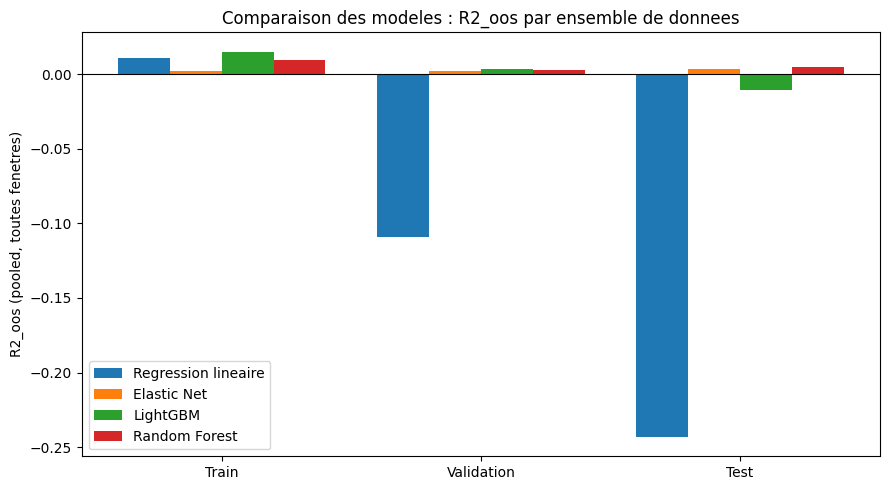

In [4]:
ensembles = ['r2_oos_train', 'r2_oos_validation', 'r2_oos_test']
etiquettes = ['Train', 'Validation', 'Test']

fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.8 / len(resultats)   # s'adapte automatiquement au nombre de modeles
positions = range(len(ensembles))

for i, (_, ligne) in enumerate(resultats.iterrows()):
    valeurs = [ligne[col] for col in ensembles]
    decalage = [p + i * largeur_barre for p in positions]
    ax.bar(decalage, valeurs, width=largeur_barre, label=ligne['modele'])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks([p + largeur_barre * (len(resultats) - 1) / 2 for p in positions])
ax.set_xticklabels(etiquettes)
ax.set_ylabel("R2_oos (pooled, toutes fenetres)")
ax.set_title("Comparaison des modeles : R2_oos par ensemble de donnees")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_COMPARAISON_PNG, dpi=150)
plt.show()

### A.5 Évolution du R²_oos test au fil des fenêtres, par modèle

Les fenêtres glissantes/extensives permettent de voir **quand** chaque modèle est bon ou
mauvais — utile pour repérer des périodes difficiles pour tous les modèles à la fois (crises,
changements de régime de marché) plutôt que des différences propres à un seul modèle.

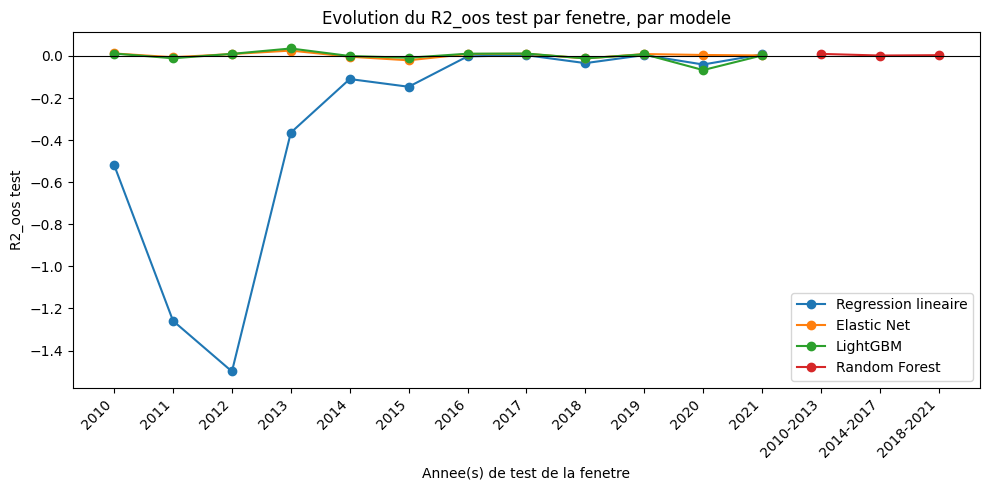

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for nom, chemin in fichiers_resultats_par_fenetre.items():
    detail = pd.read_parquet(chemin)
    ax.plot(detail['annee_test'], detail['r2_oos_test'], marker='o', label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Annee(s) de test de la fenetre")
ax.set_ylabel("R2_oos test")
ax.set_title("Evolution du R2_oos test par fenetre, par modele")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(config.FICHIER_EVOLUTION_R2_PNG, dpi=150)
plt.show()

In [6]:
resultats.to_parquet(config.FICHIER_COMPARAISON_PARQUET, index=False)
print("Comparaison sauvegardee   :", config.FICHIER_COMPARAISON_PARQUET)
print("Graphique sauvegarde      :", config.FICHIER_COMPARAISON_PNG)
print("Evolution par fenetre     :", config.FICHIER_EVOLUTION_R2_PNG)

Comparaison sauvegardee   : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.parquet
Graphique sauvegarde      : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\comparaison_modeles.png
Evolution par fenetre     : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\evolution_r2_oos_par_fenetre.png


## Partie B — Portefeuilles long-short par décile

Le `R²_oos` mesure la précision statistique d'un modèle, mais ne dit rien directement de sa
**valeur économique** : un modèle peut avoir un `R²_oos` légèrement supérieur à un autre tout
en produisant une stratégie d'investissement moins intéressante (moins stable, plus risquée...),
ou inversement. Cette partie traduit les prédictions des 4 modèles en portefeuilles
investissables, pour juger cette valeur économique directement — avec les mesures qu'utilisent
les praticiens de la finance quantitative.

1. Charger les prédictions de test déjà sauvegardées par les notebooks 04 à 07
   (`outputs/predictions_*.parquet`) — **sans aucun ré-entraînement, ni aucun rechargement de
   modèle**
2. Fusionner les 4 tables de prédictions sur `(permno, annee_mois)` en une seule
3. Construire, **mois par mois**, 10 portefeuilles par décile de rendement prédit, en
   pondération égale — la méthode standard en finance quantitative empirique (Fama-French,
   Gu, Kelly & Xiu 2020...) pour transformer un pouvoir prédictif statistique en stratégie
   d'investissement concrète
4. Former le portefeuille **long-short** de chaque modèle : acheter le décile le plus élevé
   (rendement prédit le plus fort), vendre à découvert le décile le plus faible
5. Évaluer chaque portefeuille avec des mesures de performance utilisées en finance
   quantitative : rendement annualisé, volatilité annualisée, ratio de Sharpe, ratio de
   Sortino, drawdown maximum, significativité statistique...

ℹ️ **Sur la période couverte** : avec les fenêtres glissantes/extensives, la période de
« test » n'est plus un seul bloc à la fin du panel, mais **l'union de tous les tests de
toutes les fenêtres** — potentiellement plusieurs décennies mises bout à bout (voir le
résumé des fenêtres au notebook 04, section 1). C'est *plus* représentatif d'une vraie
stratégie d'investissement suivie sur le long terme qu'un seul test récent.

### B.1 Chargement et fusion des prédictions déjà sauvegardées

Chaque fichier `predictions_*.parquet` contient une ligne par `(permno, annee_mois)` de test
(toutes fenêtres confondues pour ce modèle), avec le rendement réellement réalisé
(`excess_return`) et la prédiction du modèle. Les 4 modèles utilisant exactement les mêmes
fenêtres (mêmes paramètres dans `config.py`), leurs 4 tables de test devraient couvrir
exactement les mêmes `(permno, annee_mois)` — on le vérifie avant de fusionner.

In [7]:
tables_predictions = {}
for nom, (cle, chemin) in fichiers_predictions.items():
    table = pd.read_parquet(chemin)
    tables_predictions[cle] = table
    print(f"{nom:22s} : {table.shape}, periode {table['annee_mois'].min()} a {table['annee_mois'].max()}")

Regression lineaire    : (669550, 5), periode 201001 a 202112
Elastic Net            : (669550, 5), periode 201001 a 202112
LightGBM               : (669550, 5), periode 201001 a 202112
Random Forest          : (669550, 5), periode 201001 a 202112


In [8]:
# On part de la 1ere table (identifiants + cible) et on ajoute la colonne de prediction
# de chaque modele par une fusion sur (permno, annee_mois) -- 'inner' par securite, au cas
# ou une fenetre de bord differerait legerement d'un modele a l'autre.
cible = config.CIBLE
predictions = None

for nom, (cle, _) in fichiers_predictions.items():
    table = tables_predictions[cle][['permno', 'annee_mois', cible, 'prediction']].rename(
        columns={'prediction': f'pred_{cle}'}
    )
    if predictions is None:
        predictions = table
    else:
        predictions = pd.merge(
            predictions, table.drop(columns=[cible]),
            on=['permno', 'annee_mois'], how='inner',
        )

print(f"Predictions fusionnees : {predictions.shape}")
print(f"Periode couverte : {predictions['annee_mois'].min()} a {predictions['annee_mois'].max()}")
print(f"Nombre de mois distincts : {predictions['annee_mois'].nunique()}")
print(f"Nombre d'entreprises (permno) distinctes : {predictions['permno'].nunique()}")
predictions.head()

Predictions fusionnees : (669550, 7)
Periode couverte : 201001 a 202112
Nombre de mois distincts : 144
Nombre d'entreprises (permno) distinctes : 10080


,permno,annee_mois,excess_return,pred_reg_lineaire,pred_elastic_net,pred_lightgbm,pred_random_forest
0,10001,201001,-0.018932,0.092608,0.005419,0.001793,0.010298
1,10002,201001,0.365854,0.075142,0.005419,0.002948,-0.009216
2,10025,201001,-0.088036,0.103509,0.005419,0.001793,0.015008
3,10026,201001,0.046296,0.086112,0.005419,0.003563,0.000703
4,10032,201001,0.194171,0.103743,0.005419,0.003563,0.009687


### B.3 Construction des portefeuilles par décile (mois par mois)

Pour chaque modèle et **chaque mois séparément**, on classe les entreprises en 10 groupes
(déciles) selon leur rendement prédit :
- **décile 1** : les prédictions les plus faibles (le modèle anticipe les moins bonnes
  performances)
- **décile 10** : les prédictions les plus élevées (le modèle anticipe les meilleures
  performances)

⚠️ **Pourquoi classer mois par mois, et pas sur toute la période d'un coup ?** Un décile doit
représenter un portefeuille qu'on pourrait *réellement* construire à un instant donné, avec
les entreprises disponibles *ce mois-là*. Classer sur l'ensemble de la période mélangerait des
entreprises de mois différents dans un même "portefeuille", ce qui n'aurait aucun sens
opérationnel.

ℹ️ On utilise `rank(method='first')` avant `qcut` : ça garantit exactement 10 groupes de
taille quasi identique chaque mois, même s'il existe des prédictions strictement égales
(rares mais possibles) — un `qcut` direct sur les prédictions brutes peut échouer ou produire
moins de 10 groupes en présence d'égalités.

In [9]:
NB_DECILES = config.NB_DECILES  # 10 par defaut

# ℹ️ `assigner_decile` (et tout le reste de la partie B) vit desormais dans portefeuilles.py,
# a la racine du projet, plutot que dans cette cellule : la MEME logique est reutilisee par
# scripts/etape10_analyse_par_taille.py, qui refait exactement ces portefeuilles a
# l'interieur de chaque segment de capitalisation (voir notebook 10). Le calcul est
# strictement identique a ce qu'il etait ici.
#
# On garde le nom court disponible dans tout le notebook (il resservait en partie C).
assigner_decile = portefeuilles.assigner_decile

for nom, (cle, _) in fichiers_predictions.items():
    predictions[f'decile_{cle}'] = portefeuilles.assigner_deciles_par_mois(
        predictions, f'pred_{cle}', n=NB_DECILES,
    )

print("Deciles assignes pour les 4 modeles.")
print()
print("Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable "
      "et similaire entre deciles) :")
for nom, (cle, _) in fichiers_predictions.items():
    taille_moyenne = predictions.groupby(['annee_mois', f'decile_{cle}']).size().groupby('annee_mois').mean().mean()
    print(f"  {nom:22s} : ~{taille_moyenne:.0f} entreprises par decile en moyenne chaque mois")

Deciles assignes pour les 4 modeles.

Verification : nombre moyen d'entreprises par decile et par mois (doit etre stable et similaire entre deciles) :
  Regression lineaire    : ~465 entreprises par decile en moyenne chaque mois
  Elastic Net            : ~465 entreprises par decile en moyenne chaque mois
  LightGBM               : ~465 entreprises par decile en moyenne chaque mois
  Random Forest          : ~465 entreprises par decile en moyenne chaque mois


### B.4 Rendement mensuel de chaque décile, et portefeuille long-short

Pour chaque modèle, le rendement d'un décile un mois donné est la **moyenne équipondérée**
du rendement (réellement réalisé, pas prédit) des entreprises classées dans ce décile ce
mois-là. Le portefeuille **long-short** achète le décile 10 et vend à découvert le décile 1 :
son rendement mensuel est simplement la différence des deux.

C'est la construction standard d'un "portefeuille de spread" en finance quantitative
empirique : si le modèle a un vrai pouvoir prédictif, ce portefeuille doit dégager un
rendement positif et statistiquement significatif, sans qu'on ait besoin de connaître le
signe ou l'ampleur exacte du rendement du marché.

In [10]:
rendements_deciles = {}   # cle -> DataFrame (index=annee_mois, colonnes=1..NB_DECILES)
rendements_ls = {}        # cle -> Series (index=annee_mois), portefeuille long-short

for nom, (cle, _) in fichiers_predictions.items():
    tableau = portefeuilles.rendements_par_decile(predictions, f'decile_{cle}', cible)
    rendements_deciles[cle] = tableau
    rendements_ls[cle] = portefeuilles.rendement_long_short(tableau, nb_deciles=NB_DECILES)

rendements_portefeuilles = pd.DataFrame({
    nom: rendements_ls[cle] for nom, (cle, _) in fichiers_predictions.items()
})

print("Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :")
rendements_portefeuilles.head()

Rendements mensuels des portefeuilles long-short (decile 10 - decile 1), extrait :


,Regression lineaire,Elastic Net,LightGBM,Random Forest
annee_mois,,,,
201001,-0.006718,-0.011677,-0.008171,-0.012927
201002,0.038495,-0.001102,-0.001102,0.023435
201003,0.023871,-0.017907,-0.017907,0.033534
201004,0.012254,-0.025005,-0.069752,0.037933
201005,0.009469,-0.010919,-0.010919,0.036680


### B.5 Mesures de performance financière

On calcule, pour chaque portefeuille long-short, un ensemble de mesures standard en finance
quantitative :

- **Rendement annualisé** : moyenne mensuelle × 12
- **Volatilité annualisée** : écart-type mensuel × √12
- **Ratio de Sharpe** : rendement annualisé / volatilité annualisée. Comme `excess_return`
  est déjà un rendement *excédentaire* (net du taux sans risque, voir notebook 03,
  partie A), on n'a
  pas besoin de soustraire à nouveau `Rfree` : le ratio de Sharpe se calcule directement.
- **Ratio de Sortino** : comme le Sharpe, mais ne pénalise que la volatilité *à la baisse*
  (les mois négatifs) — plus pertinent quand les rendements ne sont pas symétriques.
- **Drawdown maximum** : la pire perte cumulée observée depuis un sommet de richesse
  antérieur, sur toute la période de test.
- **% de mois positifs** : proportion de mois où le portefeuille long-short a un rendement
  positif.
- **t-stat / p-value** : test de significativité du rendement moyen (H0 : rendement moyen
  nul). Un t-stat au-delà de ~2 (en valeur absolue) est généralement considéré comme
  significatif.
- **Asymétrie (skewness) et aplatissement (kurtosis)** : les rendements de portefeuilles
  long-short sont rarement gaussiens — utile pour juger si le Sharpe seul suffit à décrire le
  profil de risque.

In [11]:
calculer_metriques = portefeuilles.calculer_metriques

print("Mesures de performance :", ", ".join(portefeuilles.calculer_metriques(
    rendements_portefeuilles.iloc[:, 0]).keys()))

Mesures de performance : rendement_annualise, volatilite_annualisee, sharpe_ratio, sortino_ratio, max_drawdown, pct_mois_positifs, t_stat, p_value, skewness, kurtosis, n_mois


In [12]:
performance = pd.DataFrame({
    nom: calculer_metriques(rendements_portefeuilles[nom])
    for nom, _ in fichiers_predictions.items()
}).T

performance = performance.sort_values('sharpe_ratio', ascending=False)

# 'cle_experience' identifie, pour CHAQUE modele, A QUEL lancement de 04/05/06/07 (quels
# parametres generaux + specifiques) ces predictions -- et donc ces mesures de portefeuille
# -- correspondent : la MEME cle deja ecrite dans outputs/resultats_*.parquet (voir
# notebooks 04-07, section 7, et journal.cle_experience_actuelle). Sauvegardee plus bas
# (B.8) dans outputs/performance_portefeuilles.parquet : c'est ce qui permet au notebook 09
# de relier CES mesures a LA BONNE ligne de son tableau de comparaison (voir sa section 2).
performance['cle_experience'] = resultats.set_index('modele')['cle_experience']

print("Performance des portefeuilles long-short (decile 10 - decile 1), par modele :")
performance.drop(columns='cle_experience').round(4)

Performance des portefeuilles long-short (decile 10 - decile 1), par modele :


,rendement_annualise,volatilite_annualisee,sharpe_ratio,sortino_ratio,max_drawdown,pct_mois_positifs,t_stat,p_value,skewness,kurtosis,n_mois
Regression lineaire,0.1135,0.1076,1.0553,1.8536,-0.1148,0.6319,3.6558,0.0004,-0.1663,0.3017,144.0
Random Forest,0.1468,0.1600,0.9175,1.4999,-0.3529,0.6458,3.1783,0.0018,-0.3392,1.0634,144.0
Elastic Net,-0.0108,0.0639,-0.1693,-0.2607,-0.2595,0.4583,-0.5866,0.5584,1.4306,9.7393,144.0
LightGBM,-0.0373,0.0955,-0.3912,-0.5149,-0.3908,0.4375,-1.3550,0.1775,0.1651,8.4977,144.0


### B.6 Le rendement est-il monotone par décile ? (diagnostic de qualité du signal)

Un signe de bonne qualité du signal prédictif : le rendement moyen des déciles devrait
**augmenter globalement du décile 1 au décile 10**. Si le classement du modèle n'a aucune
valeur, les rendements moyens par décile devraient être plats (à peu près identiques quel
que soit le décile) plutôt que croissants.

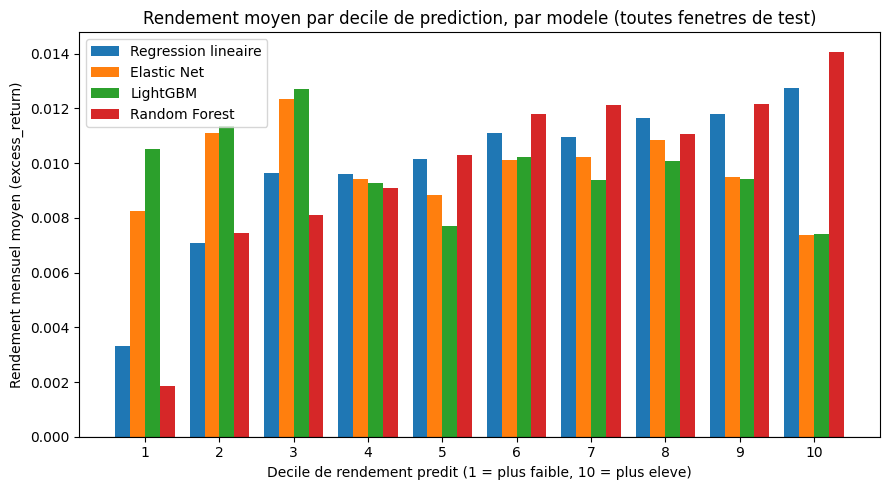

In [13]:
rendement_moyen_par_decile = pd.DataFrame({
    nom: rendements_deciles[cle].mean()
    for nom, (cle, _) in fichiers_predictions.items()
})
rendement_moyen_par_decile.index.name = 'decile'

fig, ax = plt.subplots(figsize=(9, 5))

largeur_barre = 0.8 / len(fichiers_predictions)   # s'adapte au nombre de modeles
positions = np.arange(NB_DECILES)

for i, (nom, _) in enumerate(fichiers_predictions.items()):
    valeurs = rendement_moyen_par_decile[nom].values
    decalage = positions + i * largeur_barre
    ax.bar(decalage, valeurs, width=largeur_barre, label=nom)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(positions + largeur_barre * (len(fichiers_predictions) - 1) / 2)
ax.set_xticklabels(range(1, NB_DECILES + 1))
ax.set_xlabel("Decile de rendement predit (1 = plus faible, 10 = plus eleve)")
ax.set_ylabel("Rendement mensuel moyen (excess_return)")
ax.set_title("Rendement moyen par decile de prediction, par modele (toutes fenetres de test)")
ax.legend()
plt.tight_layout()

plt.savefig(config.FICHIER_DECILES_PNG, dpi=150)
plt.show()

### B.7 Richesse cumulée des 4 portefeuilles long-short

On trace la richesse cumulée (base 1, sans capital additionnel ni retrait) de chaque
portefeuille long-short sur toute la période de test (toutes fenêtres mises bout à bout),
pour visualiser à la fois la performance globale et la régularité (ou l'irrégularité) des
gains dans le temps.

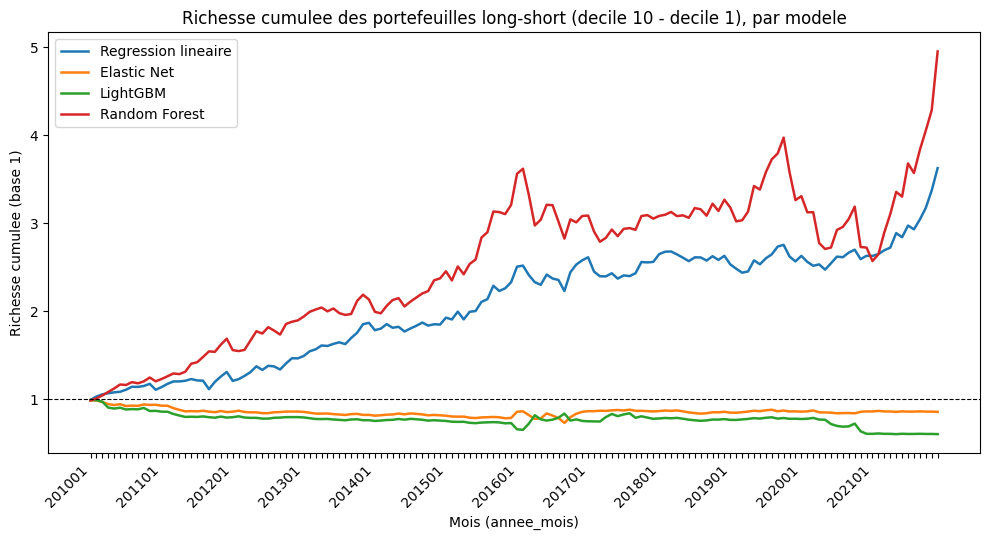

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for nom, _ in fichiers_predictions.items():
    richesse_cumulee = (1 + rendements_portefeuilles[nom]).cumprod()
    ax.plot(richesse_cumulee.index, richesse_cumulee.values, label=nom, linewidth=1.8)

ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Mois (annee_mois)")
ax.set_ylabel("Richesse cumulee (base 1)")
ax.set_title("Richesse cumulee des portefeuilles long-short (decile 10 - decile 1), par modele")
ax.legend()

# On n'affiche qu'une etiquette sur ~12 sur l'axe des mois, sinon illisible
nb_mois = len(rendements_portefeuilles.index)
pas_etiquette = max(nb_mois // 12, 1)
ax.set_xticks(ax.get_xticks()[::1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, etiquette in enumerate(ax.xaxis.get_ticklabels()):
    if i % pas_etiquette != 0:
        etiquette.set_visible(False)

plt.tight_layout()
plt.savefig(config.FICHIER_CUMULATIF_PNG, dpi=150)
plt.show()

### B.8 Comparaison finale et sauvegarde

⚠️ Comme pour le `R²_oos` en partie A, un ratio de Sharpe élevé ne dit rien à lui seul de
la qualité *économique* du modèle sans regarder aussi le drawdown maximum et la
significativité statistique (`t_stat` / `p_value`) : un Sharpe flatteur porté par 2-3 mois
exceptionnels sur une courte période de test n'a pas la même valeur qu'un Sharpe plus modeste
mais régulier sur une longue période.

ℹ️ **A noter** : en plus du simple instantané `outputs/performance_portefeuilles.parquet`
(écrasé à chaque lancement), ces mesures sont aussi **ajoutées** à
`outputs/historique_performance_portefeuilles.parquet` -- un fichier **jamais écrasé**
(comme `outputs/journal_experiences.parquet`), dédupliqué par `cle_experience` (voir B.5 et
`journal.enregistrer_performances_portefeuilles`) : relancer 08 sur les mêmes prédictions
n'y ajoute rien de plus, mais un changement de modèle/paramètres suivi d'un nouveau
lancement de 08 y **ajoute** une ligne sans supprimer celle du lancement précédent. C'est
cet historique que le notebook 09 utilise pour afficher le Sharpe (etc.) de **chaque**
expérience du journal déjà évaluée par 08 au moins une fois -- `NaN` uniquement pour celles
qui n'ont encore jamais été évaluées (voir sa section 2).

In [15]:
meilleur_modele = performance['sharpe_ratio'].idxmax()
print(f"Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : {meilleur_modele} "
      f"(Sharpe = {performance.loc[meilleur_modele, 'sharpe_ratio']:.3f})")
print()
print(performance.drop(columns='cle_experience').loc[meilleur_modele].round(4))

Meilleur portefeuille long-short sur TEST (ratio de Sharpe) : Regression lineaire (Sharpe = 1.055)

rendement_annualise        0.1135
volatilite_annualisee      0.1076
sharpe_ratio               1.0553
sortino_ratio              1.8536
max_drawdown              -0.1148
pct_mois_positifs          0.6319
t_stat                     3.6558
p_value                    0.0004
skewness                  -0.1663
kurtosis                   0.3017
n_mois                   144.0000
Name: Regression lineaire, dtype: float64


In [16]:
rendements_portefeuilles.to_parquet(config.FICHIER_RENDEMENTS_PORTEFEUILLES)
performance.to_parquet(config.FICHIER_PERFORMANCE_PORTEFEUILLES)

print("Rendements mensuels sauvegardes  :", config.FICHIER_RENDEMENTS_PORTEFEUILLES)
print("Tableau de performance sauvegarde:", config.FICHIER_PERFORMANCE_PORTEFEUILLES)
print("Graphique par decile sauvegarde  :", config.FICHIER_DECILES_PNG)
print("Graphique richesse cumulee sauve :", config.FICHIER_CUMULATIF_PNG)

# On AJOUTE (sans rien ecraser) ces mesures a l'historique cumulatif -- voir B.8
# ci-dessus et journal.py. Dedupliqué par cle_experience : relancer 08 sur les memes
# predictions n'ajoute rien de plus.
print()
journal.enregistrer_performances_portefeuilles(performance)
print("Historique cumulatif (jamais ecrase) :", config.FICHIER_HISTORIQUE_PERFORMANCE_PORTEFEUILLES)

Rendements mensuels sauvegardes  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\rendements_portefeuilles_deciles.parquet
Tableau de performance sauvegarde: C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_portefeuilles.parquet
Graphique par decile sauvegarde  : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_rendement_par_decile.png
Graphique richesse cumulee sauve : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_richesse_cumulee.png

Historique des performances de portefeuille : rien de nouveau (toutes les experiences de ce lancement y figurent deja).
Historique cumulatif (jamais ecrase) : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\historique_performance_portefeuilles.parquet


### B.9 Constructions alternatives — de combien le Sharpe bouge-t-il ?

Tout ce qui précède repose sur **une** construction : long-short **équipondéré**, décile 10
moins décile 1, recalculé mois par mois. C'est la référence du projet, et rien de ce qui suit
ne la remplace — le tableau de performance sauvegardé en B.8 et le journal des expériences
continuent de porter sur elle seule.

Cette section rejoue **exactement les mêmes prédictions** (aucun ré-entraînement, aucun
fichier réécrit) sous d'autres constructions, pour répondre à une question simple : *quelle
part du Sharpe vient du modèle, et quelle part vient de la façon dont on transforme ses
prédictions en portefeuille ?* Deux leviers, combinés deux à deux :

| | Long-short (D10 − D1) | Long only (top *X* %) |
|---|---|---|
| **Équipondéré** | la référence du projet | ↓ |
| **Pondéré par la capitalisation** | → | les deux à la fois |

**Pondération par la capitalisation** (`config.PONDERATION_PAR_CAPITALISATION`). Un
portefeuille équipondéré met autant d'argent sur une micro-cap illiquide que sur Apple. Or
c'est précisément chez les petites capitalisations que les modèles d'apprentissage trouvent
l'essentiel de leur signal. Pondérer par `mvel1_brut` — la capitalisation du mois *t*, donc
connue au moment de la formation et sans information du futur — reflète où l'argent peut
**réellement** être investi. C'est le test de robustesse de Gu, Kelly & Xiu (2020) : le Sharpe
s'effondre généralement au passage. Si c'est le cas ici, ce n'est pas un échec, c'est un
résultat — et il recoupe directement le notebook 10 (analyse par taille).

**Long only** (`config.PCT_LONG_ONLY`, 20 % par défaut). Beaucoup d'investisseurs
institutionnels ne peuvent pas vendre à découvert : on achète les *X* % des titres les mieux
notés, sans jambe courte. ⚠️ **Ce portefeuille n'est pas comparable au long-short** : il porte
l'exposition au marché (bêta ≈ 1), que le long-short neutralise en grande partie. Son Sharpe
se lit contre celui du marché. Ce qu'il dit en revanche très bien : si le long-short brille
mais que le long only s'effondre, toute la performance vient de la **jambe courte** — donc
d'une stratégie que beaucoup ne peuvent pas mettre en œuvre.

⚠️ **Aucun coût de transaction n'est déduit nulle part**, et ces constructions n'ont pas le
même turnover (le long only en a nettement moins que le long-short, qui doit refaire ses deux
jambes chaque mois). Le classement ci-dessous est **brut** : c'est la limite à énoncer
explicitement dans le mémoire.

In [17]:
# La capitalisation vit dans le PANEL (colonne ecrite par l'etape 03), pas dans les fichiers
# de predictions : il faut la fusionner. ⚠️ C'est `mvel1_brut`, la capitalisation AVANT
# winsorizing et rank transform -- `mvel1` vit dans [-1, 1] et ne serait pas un poids valide.
COLONNE_CAPI = config.COLONNE_MVEL1_BRUT

predictions_alt = predictions.copy()
predictions_alt['annee_mois'] = predictions_alt['annee_mois'].astype(str)
colonne_poids = None

if config.PONDERATION_PAR_CAPITALISATION:
    capitalisations = pd.read_parquet(
        config.FICHIER_PANEL_MODELISATION, columns=['permno', 'annee_mois', COLONNE_CAPI])
    capitalisations['annee_mois'] = capitalisations['annee_mois'].astype(str)
    predictions_alt = predictions_alt.merge(
        capitalisations, on=['permno', 'annee_mois'], how='left')
    colonne_poids = COLONNE_CAPI

    pct_manquant = float(predictions_alt[COLONNE_CAPI].isna().mean() * 100)
    print(f"Capitalisation fusionnee : {100 - pct_manquant:.1f} % des lignes renseignees.")
    if pct_manquant > 5:
        print(f"⚠️ {pct_manquant:.1f} % de capitalisations manquantes. Les portefeuilles")
        print("   ponderes ecartent ces lignes : ils ne portent donc pas exactement sur le")
        print("   meme univers que les equiponderes, et l'ecart de Sharpe melange alors deux")
        print("   effets. A verifier avant de conclure quoi que ce soit.")
else:
    print("config.PONDERATION_PAR_CAPITALISATION = False :")
    print("  seules les variantes equiponderees sont calculees.")

print(f"Long only : les {config.PCT_LONG_ONLY * 100:.0f} % des titres les mieux notes "
      f"(~{config.PCT_LONG_ONLY * NB_DECILES:.0f} deciles sur {NB_DECILES}).")

Capitalisation fusionnee : 100.0 % des lignes renseignees.
Long only : les 20 % des titres les mieux notes (~2 deciles sur 10).


In [18]:
# ⚠️ MEMES predictions, MEME cible, MEMES mois : tout ecart de Sharpe entre deux lignes vient
# uniquement de la construction du portefeuille, jamais du modele. C'est ce qui rend ce
# tableau lisible -- et c'est pour cela qu'aucun ré-entrainement n'est necessaire.
comparaisons = {}
for nom, (cle, _) in fichiers_predictions.items():
    comparaisons[nom] = portefeuilles.comparer_constructions(
        predictions_alt,
        colonne_prediction=f'pred_{cle}',
        colonne_cible=cible,
        nb_deciles=NB_DECILES,
        colonne_poids=colonne_poids,
        pct_long_only=config.PCT_LONG_ONLY,
    )

performance_constructions = pd.concat(
    {nom: c['performance'] for nom, c in comparaisons.items()},
    names=['modele', 'construction'])

colonnes_alt = ['sharpe_ratio', 'pct_mois_positifs']
performance_constructions[colonnes_alt].round(4)

sharpe_ratio  pct_mois_positifs
modele              construction                                                   
Regression lineaire Long-short equipondere                1.0553             0.6319
                    Long only top 20% equipondere         0.8066             0.6667
                    Long-short pondere capi               0.9516             0.6319
                    Long only top 20% pondere capi        0.9339             0.6736
Elastic Net         Long-short equipondere               -0.1693             0.4583
                    Long only top 20% equipondere         0.5911             0.6597
                    Long-short pondere capi               0.4100             0.5625
                    Long only top 20% pondere capi        0.9302             0.6806
LightGBM            Long-short equipondere               -0.3912             0.4375
                    Long only top 20% equipondere         0.5502             0.6458
                    Long-short pondere capi               0.0300             0.5278
                    Long only top 20% pondere capi        0.9291             0.6736
Random Forest       Long-short equipondere                0.9175             0.6458
                    Long only top 20% equipondere         0.8576             0.6389
                    Long-short pondere capi               0.5615             0.5833
                    Long only top 20% pondere capi        0.9661             0.6319

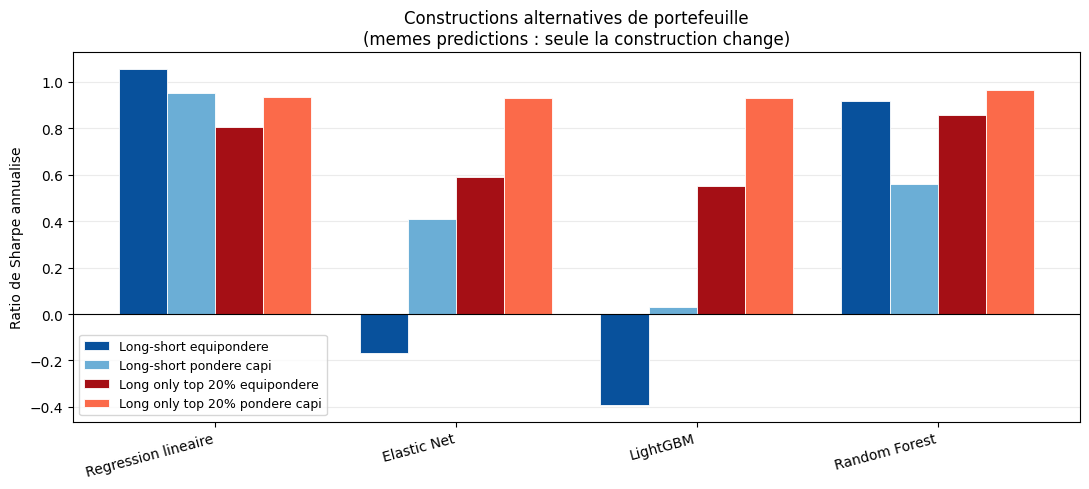

Ecart moyen de Sharpe par rapport a la construction de reference (Long-short equipondere) :
  Long-short pondere capi            : +0.135  (au-dessus de la reference)
  Long only top 20% equipondere      : +0.348  (au-dessus de la reference)
  Long only top 20% pondere capi     : +0.587  (au-dessus de la reference)


In [19]:
# Le graphique qui resume la section : un groupe de barres par modele, une barre par
# construction. C'est la figure a mettre dans le memoire pour ce point.
tableau_sharpe = performance_constructions['sharpe_ratio'].unstack('construction')

TAILLE_FIGURE = (11, 5)

# L'etiquette du long only depend de config.PCT_LONG_ONLY : on la reconstruit plutot que
# de la coder en dur, sinon changer PCT_LONG_ONLY casse silencieusement l'ordre ci-dessous.
ETIQUETTE_LONG = f"Long only top {int(round(config.PCT_LONG_ONLY * 100))}%"

# Ordre voulu : les deux long-short d'abord, puis les deux long only.
ORDRE_CONSTRUCTIONS = [
    'Long-short equipondere',
    'Long-short pondere capi',
    f"{ETIQUETTE_LONG} equipondere",
    f"{ETIQUETTE_LONG} pondere capi",
]

# Long-short = bleus (fonce -> clair), long only = rouges (fonce -> clair).
COULEURS_CONSTRUCTIONS = {
    'Long-short equipondere':            '#08519c',
    'Long-short pondere capi':           '#6baed6',
    f"{ETIQUETTE_LONG} equipondere":     '#a50f15',
    f"{ETIQUETTE_LONG} pondere capi":    '#fb6a4a',
}

# Si PONDERATION_PAR_CAPITALISATION = False, seules 2 constructions existent : on ne garde
# que celles reellement presentes, sans planter.
constructions = [c for c in ORDRE_CONSTRUCTIONS if c in tableau_sharpe.columns]

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)
largeur = 0.8 / len(constructions)
positions = np.arange(len(tableau_sharpe))

for i, construction in enumerate(constructions):
    ax.bar(positions + i * largeur, tableau_sharpe[construction].values,
           width=largeur, label=construction,
           color=COULEURS_CONSTRUCTIONS[construction],
           edgecolor='white', linewidth=0.6)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(positions + largeur * (len(constructions) - 1) / 2)
ax.set_xticklabels(tableau_sharpe.index, rotation=15, ha='right')
ax.set_ylabel("Ratio de Sharpe annualise")
ax.set_title("Constructions alternatives de portefeuille\n"
             "(memes predictions : seule la construction change)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(config.FICHIER_CONSTRUCTIONS_PNG, dpi=150)
plt.show()

REFERENCE = 'Long-short equipondere'
print(f"Ecart moyen de Sharpe par rapport a la construction de reference ({REFERENCE}) :")
for construction in constructions:
    if construction == REFERENCE:
        continue
    ecart = float((tableau_sharpe[construction] - tableau_sharpe[REFERENCE]).mean())
    signe = "au-dessus" if ecart > 0 else "en dessous"
    print(f"  {construction:34s} : {ecart:+.3f}  ({signe} de la reference)")

In [20]:
# ⚠️ Fichier SEPARE : `performance_portefeuilles.parquet` (sauvegarde en B.8) reste
# strictement inchange, ainsi que le journal des experiences. Ces constructions alternatives
# sont un diagnostic, pas une experience : elles ne portent aucune cle d'experience nouvelle
# puisqu'elles reposent sur les MEMES predictions que celles deja enregistrees.
performance_constructions.to_parquet(config.FICHIER_PERFORMANCE_CONSTRUCTIONS)
print("Constructions alternatives sauvegardees :", config.FICHIER_PERFORMANCE_CONSTRUCTIONS)
print("Graphique sauvegarde                    :", config.FICHIER_CONSTRUCTIONS_PNG)

Constructions alternatives sauvegardees : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\performance_constructions.parquet
Graphique sauvegarde                    : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\portefeuilles_constructions_alternatives.png


⚠️ Limites valables pour toute la partie : portefeuilles sans coût de transaction ni turnover
déduit, et rendements déjà excédentaires (nets du taux sans risque), d'où l'absence de
soustraction supplémentaire dans le ratio de Sharpe.

## Partie C — Portefeuille combiné (ensemble de plusieurs modèles)

Les parties A et B répondent à « **quel** modèle choisir ? ». Cette partie pose une autre
question : et si on n'avait pas à choisir ?

**L'idée.** Deux modèles qui se trompent sur des choses **différentes** se complètent. La
moyenne de leurs prévisions a une erreur quadratique plus faible que chacune prise isolément,
même quand l'un des deux est nettement moins bon — c'est le résultat fondateur de
**Bates & Granger (1969)**, et c'est exactement l'argument de la diversification d'un
portefeuille, appliqué aux prévisions plutôt qu'aux actifs. Pour deux prévisions d'erreurs de
variances $\sigma_1^2$, $\sigma_2^2$ et de corrélation $\rho$, la combinaison de poids $w$ et
$1-w$ a une variance d'erreur

$$w^2\sigma_1^2 + (1-w)^2\sigma_2^2 + 2w(1-w)\rho\,\sigma_1\sigma_2$$

qui, pour un $w$ bien choisi, est **inférieure à $\min(\sigma_1^2,\sigma_2^2)$** dès que
$\rho$ est assez faible. D'où l'intérêt de combiner des familles **différentes** : une forêt
et un boosting se trompent différemment, deux Elastic Net aux `alpha` voisins non.

**Cinq méthodes de pondération**, toutes pilotées par `config.METHODE_PONDERATION_ENSEMBLE` :

| Méthode | Poids | Principe |
|---|---|---|
| `manuelle` | constants | ceux que tu fixes dans `config.POIDS_ENSEMBLE` |
| `egale` | constants | 1/N — la référence à battre (voir plus bas) |
| `r2_validation` | constants | ∝ au `R²_oos` de **validation** de chaque modèle |
| `inverse_variance` | variables | ∝ 1/EQM, ré-estimés chaque mois (Bates & Granger, 1969) |
| `moindres_carres` | variables | les poids qui minimisent l'erreur de la combinaison, ré-estimés chaque mois (Granger & Ramanathan, 1984 ; *stacking*) |

⚠️ **Le point critique : aucune fuite de données.** Les poids appliqués au mois *t* ne sont
jamais estimés en utilisant le mois *t* lui-même, ni aucun mois postérieur — uniquement les
mois strictement antérieurs (au plus `FENETRE_PONDERATION_ENSEMBLE_MOIS` d'entre eux). Un
portefeuille combiné construit avec les poids optimaux calculés sur **toute** la période de
test afficherait un Sharpe flatteur et parfaitement irréalisable : c'est l'erreur classique de
cet exercice. Les tout premiers mois, faute d'historique suffisant
(`MOIS_MINIMUM_PONDERATION_ENSEMBLE`), retombent sur des poids égaux.

In [21]:
# --- Configuration de l'ensemble (config.py, section "Portefeuille COMBINE") ---
modeles_ensemble = ensemble.verifier_configuration(list(fichiers_predictions))
cle_par_modele = {nom: cle for nom, (cle, _) in fichiers_predictions.items()}
colonnes_par_modele = {m: f'pred_{cle_par_modele[m]}' for m in modeles_ensemble}

print(f"Modeles combines : {modeles_ensemble}")
print(f"Methode de ponderation : {config.METHODE_PONDERATION_ENSEMBLE}")
print(f"  -> {ensemble.description()}")
if config.METHODE_PONDERATION_ENSEMBLE in ensemble.METHODES_GLISSANTES:
    fenetre = config.FENETRE_PONDERATION_ENSEMBLE_MOIS
    print(f"  Fenetre d'estimation : {fenetre if fenetre else 'tout l historique passe'} mois")
    print(f"  Historique minimum   : {config.MOIS_MINIMUM_PONDERATION_ENSEMBLE} mois "
          "(avant : poids egaux)")
if config.METHODE_PONDERATION_ENSEMBLE == 'moindres_carres':
    print(f"  Poids contraints >= 0 et de somme 1 : {config.POIDS_ENSEMBLE_POSITIFS}")

Modeles combines : ['LightGBM', 'Random Forest']
Methode de ponderation : moindres_carres
  -> poids de moindres carres (Granger & Ramanathan 1984 / stacking), ré-estimes chaque mois sur les mois de test deja passes
  Fenetre d'estimation : 60 mois
  Historique minimum   : 24 mois (avant : poids egaux)
  Poids contraints >= 0 et de somme 1 : True


### C.1 Calcul des poids

Pour les deux méthodes glissantes, les poids sont ré-estimés **mois par mois**. Le calcul
passe par les matrices de produits croisés de chaque mois, cumulées sur la fenêtre : on ne
retouche jamais aux lignes individuelles, seulement à des matrices *k × k* (*k* = nombre de
modèles combinés). C'est ce qui rend l'estimation instantanée même sur des centaines de
milliers de lignes (voir `ensemble.py`).

In [22]:
modeles_ensemble = ensemble.verifier_configuration(list(fichiers_predictions))
cle_par_modele = {nom: cle for nom, (cle, _) in fichiers_predictions.items()}
colonnes_par_modele = {m: f'pred_{cle_par_modele[m]}' for m in modeles_ensemble}
scores_validation = resultats.set_index('modele')['r2_oos_validation'].to_dict()

comparaison_ensembles = ensemble.comparer_methodes(
    predictions, colonnes_par_modele, cible, nb_deciles=NB_DECILES,
    methodes=config.METHODES_ENSEMBLE_COMPAREES,
    scores_validation=scores_validation,
    fenetre_mois=config.FENETRE_PONDERATION_ENSEMBLE_MOIS,
    mois_minimum=config.MOIS_MINIMUM_PONDERATION_ENSEMBLE,
    positifs=config.POIDS_ENSEMBLE_POSITIFS,
)
methodes_ensemble = comparaison_ensembles['methodes']

print(f"Modeles combines ({len(modeles_ensemble)}) : {modeles_ensemble}")
print(f"Methode de reference (journal) : {config.METHODE_PONDERATION_ENSEMBLE}")
print()
print("Poids MOYEN de chaque modele sur la periode, par methode de ponderation :")
display(comparaison_ensembles['poids_moyens'].round(3))

Modeles combines (2) : ['LightGBM', 'Random Forest']
Methode de reference (journal) : moindres_carres

Poids MOYEN de chaque modele sur la periode, par methode de ponderation :


,egale,r2_validation,inverse_variance,moindres_carres
LightGBM,0.5,0.522,0.499,0.43
Random Forest,0.5,0.478,0.501,0.57


### C.2 Évolution des poids dans le temps

Mêmes modèles, mêmes prédictions : seule la règle de pondération change d'un panneau à
l'autre. Le trait pointillé marque la fin du démarrage, avant lequel les méthodes glissantes
retombent volontairement sur des poids égaux, faute d'historique.

- **`egale`** : 1/N, aucun paramètre estimé. La référence à battre.
- **`r2_validation`** : plat et quasi identique à `egale` — les R² de validation des deux
  modèles sont trop proches pour les départager.
- **`inverse_variance`** : plat aussi, mais pour une raison mécanique. Avec un R²_oos de
  0,005, chaque modèle laisse ~99,5 % de la variance inexpliquée : le rapport de leurs EQM
  vaut ~1,001, donc les poids restent collés à 50/50.
- **`moindres_carres`** : le seul qui bouge, et ce mouvement est du bruit d'estimation. Deux
  prédictions très corrélées rendent la régression mal conditionnée ; sous contrainte de
  poids positifs, la solution bascule d'un bord à l'autre du simplexe.

Trois règles sur quatre convergent vers 50/50. Le choix de la pondération n'est donc pas un
levier de performance ici — ce qui dispense d'avoir à justifier lequel a été retenu.

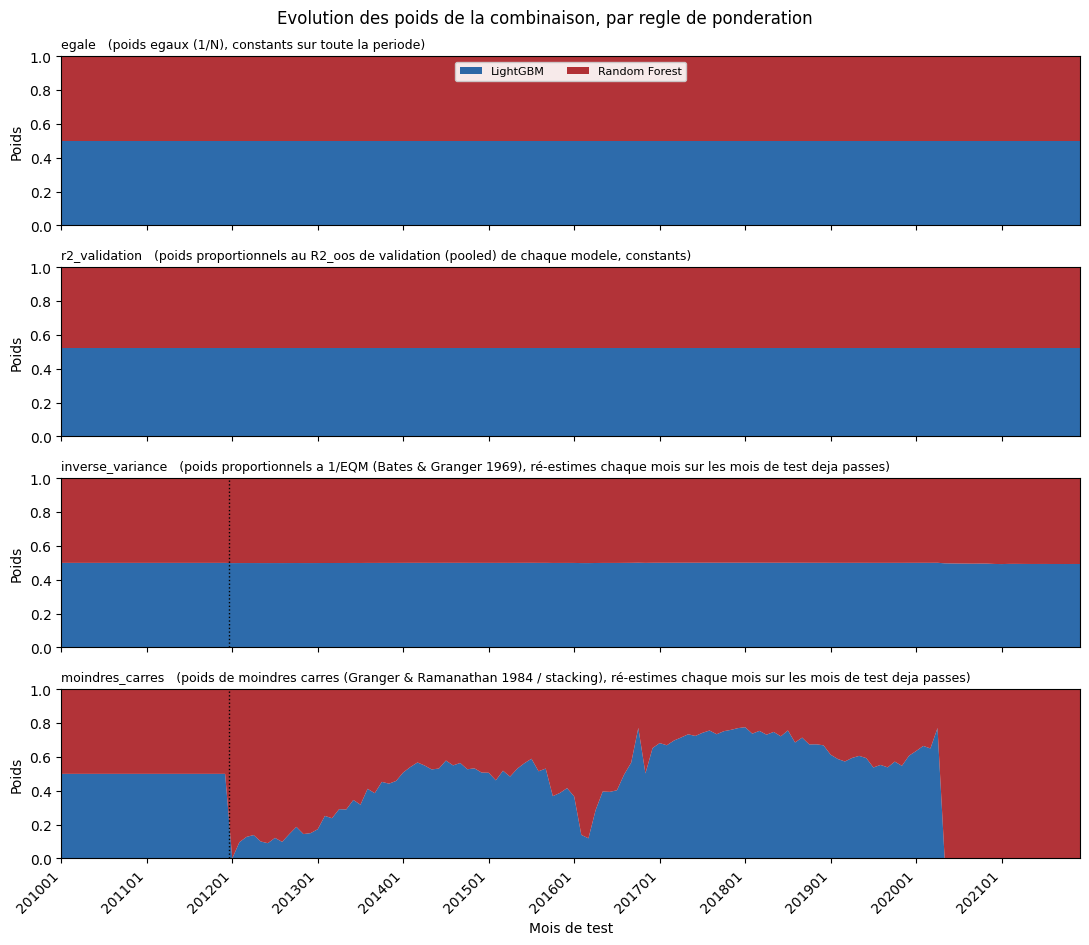

In [23]:
# Une couleur PAR MODELE, identique dans les 4 panneaux : c'est ce qui permet de comparer
# les panneaux entre eux. La palette s'etend automatiquement si tu ajoutes des modeles.
PALETTE_MODELES = ['#08519c', '#a50f15', '#238b45', '#f16913', '#6a51a3', '#8c6d31']
COULEURS_MODELES = {m: PALETTE_MODELES[i % len(PALETTE_MODELES)]
                    for i, m in enumerate(modeles_ensemble)}

HAUTEUR_PAR_PANNEAU = 2.4          # ajuste ces deux constantes a la main
LARGEUR_FIGURE = 11.0
TAILLE_FIGURE = (LARGEUR_FIGURE, HAUTEUR_PAR_PANNEAU * len(methodes_ensemble))

fig, axes = plt.subplots(len(methodes_ensemble), 1, sharex=True, figsize=TAILLE_FIGURE)
axes = np.atleast_1d(axes)

mois = comparaison_ensembles['poids'][methodes_ensemble[0]].index
x = np.arange(len(mois))

for ax, methode in zip(axes, methodes_ensemble):
    tableau = comparaison_ensembles['poids'][methode]
    ax.stackplot(x, *[tableau[m].values for m in modeles_ensemble],
                 labels=modeles_ensemble,
                 colors=[COULEURS_MODELES[m] for m in modeles_ensemble], alpha=0.85)
    ax.set_xlim(0, len(mois) - 1)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Poids")
    ax.set_title(f"{methode}   ({ensemble.description(methode)})", fontsize=9, loc='left')

    # Les methodes glissantes retombent sur des poids EGAUX tant que l'historique est trop
    # court : avant ce trait, elles sont identiques a 'egale' par construction, pas par
    # coincidence. Sans ce repere le lecteur croit a un bug.
    n_egaux = int(comparaison_ensembles['diagnostics'].loc[
        methode, 'n_mois_poids_egaux_faute_historique'])
    if n_egaux > 0:
        ax.axvline(n_egaux - 0.5, color='black', linewidth=1.0, linestyle=':')

positions_x = range(0, len(mois), max(len(mois) // 12, 1))
axes[-1].set_xticks(list(positions_x))
axes[-1].set_xticklabels([mois[i] for i in positions_x], rotation=45, ha='right')
axes[-1].set_xlabel("Mois de test")
axes[0].legend(loc='upper center', ncol=len(modeles_ensemble),
               fontsize=8, framealpha=0.9)
fig.suptitle("Evolution des poids de la combinaison, par regle de ponderation",
             fontsize=12)
plt.tight_layout()
plt.savefig(config.FICHIER_ENSEMBLES_POIDS_PNG, dpi=150)
plt.show()

### C.3 Les modèles combinés sont-ils vraiment complémentaires ?

La condition pour que la combinaison apporte quelque chose n'est pas que les modèles soient
bons, mais qu'ils se trompent **différemment**. C'est donc la corrélation de leurs **erreurs**
qu'il faut regarder, pas celle de leurs prédictions :

- **Corrélation des erreurs proche de 1** → les modèles se trompent au même moment sur les
  mêmes titres. Les combiner n'apportera presque rien.
- **Corrélation nettement inférieure à 1** → il y a de la diversification à récupérer, et
  c'est exactement ce que la combinaison exploite.

In [31]:
# ⚠️ C'est la correlation des ERREURS qui decide du gain de la combinaison, pas celle des
# predictions : deux modeles peuvent avoir des predictions tres correlees (ils classent les
# titres dans le meme ordre) tout en se trompant a des moments differents. C'est le second
# cas qui laisse de la place a la diversification.
erreurs = pd.DataFrame({
    m: predictions[cible] - predictions[colonnes_par_modele[m]] for m in modeles_ensemble
})
correlation_erreurs = erreurs.corr()

# Les k(k-1)/2 coefficients hors diagonale, sans passer par un masque + stack (dont le
# dropna implicite declenche un FutureWarning sur les pandas recents).
triangle = np.triu_indices(len(modeles_ensemble), k=1)
correlations_hors_diagonale = correlation_erreurs.to_numpy()[triangle]

if len(modeles_ensemble) == 2:
    # Avec 2 modeles la "matrice" se reduit a un seul coefficient : une phrase est plus
    # lisible qu'un tableau 2x2 dont trois cases sur quatre sont connues d'avance.
    a, b = modeles_ensemble
    print(f"Correlation des erreurs entre {a} et {b} : "
          f"{correlations_hors_diagonale[0]:.3f}")
else:
    print("Correlation des ERREURS entre modeles combines :")
    display(correlation_erreurs.round(3))
    print(f"Moyenne hors diagonale : {correlations_hors_diagonale.mean():.3f}   "
          f"(min {correlations_hors_diagonale.min():.3f}, "
          f"max {correlations_hors_diagonale.max():.3f})")

if correlations_hors_diagonale.max() > 0.95:
    print("-> Tres elevee : ces modeles font quasiment les memes erreurs, le gain de la")
    print("   combinaison sera marginal quelle que soit la regle de ponderation.")

Correlation des erreurs entre LightGBM et Random Forest : 0.997
-> Tres elevee : ces modeles font quasiment les memes erreurs, le gain de la
   combinaison sera marginal quelle que soit la regle de ponderation.


### C.4 Prédiction combinée et R²_oos

La prédiction combinée de chaque ligne est la somme des prédictions des modèles, pondérée par
les poids **du mois de cette ligne**. Son `R²_oos` se calcule exactement comme celui des
modèles individuels (même métrique, mêmes lignes) : les chiffres sont directement comparables
à ceux de la partie A.

In [25]:
r2_composants = comparaison_ensembles['r2_oos_composants']
meilleur_composant = float(r2_composants.max())

comparaison_r2 = pd.DataFrame({
    'r2_oos_test': pd.concat([
        r2_composants.rename(index=lambda m: f"(composant) {m}"),
        comparaison_ensembles['r2_oos'].rename(index=lambda m: f"Ensemble — {m}"),
    ])
})
comparaison_r2['ecart_vs_meilleur_composant'] = (
    comparaison_r2['r2_oos_test'] - meilleur_composant)

print("R2_oos test — memes lignes pour tous, donc directement comparables :")
comparaison_r2.round(5)

R2_oos test — memes lignes pour tous, donc directement comparables :


,r2_oos_test,ecart_vs_meilleur_composant
(composant) LightGBM,-0.01061,-0.01544
(composant) Random Forest,0.00482,0.00000
Ensemble — egale,-0.00122,-0.00604
Ensemble — r2_validation,-0.00157,-0.00639
Ensemble — inverse_variance,-0.00117,-0.00600
Ensemble — moindres_carres,0.00177,-0.00305


### C.5 Portefeuille long-short de l'ensemble

Exactement la même construction qu'en partie B (déciles mois par mois, achat du décile
`NB_DECILES`, vente à découvert du décile 1, équipondéré) — appliquée cette fois à la
prédiction combinée. Les mesures obtenues sont donc directement comparables à celles des
modèles individuels.

ℹ️ Le niveau des poids n'a aucune importance pour le classement en déciles (multiplier toutes
les prédictions d'un mois par une constante ne change pas leur ordre) : ce sont les poids
**relatifs** entre modèles qui font le travail.

In [26]:
performance_ensembles = comparaison_ensembles['performance']

colonnes_affichees = ['rendement_annualise', 'volatilite_annualisee', 'sharpe_ratio',
                      'max_drawdown', 't_stat']
print("Portefeuille long-short de la combinaison, par regle de ponderation :")
performance_ensembles[colonnes_affichees].round(4)

Portefeuille long-short de la combinaison, par regle de ponderation :


,rendement_annualise,volatilite_annualisee,sharpe_ratio,max_drawdown,t_stat
egale,0.1371,0.1620,0.8464,-0.4400,2.9320
r2_validation,0.1369,0.1620,0.8452,-0.4442,2.9279
inverse_variance,0.1371,0.1619,0.8470,-0.4395,2.9340
moindres_carres,0.1438,0.1567,0.9179,-0.3529,3.1796


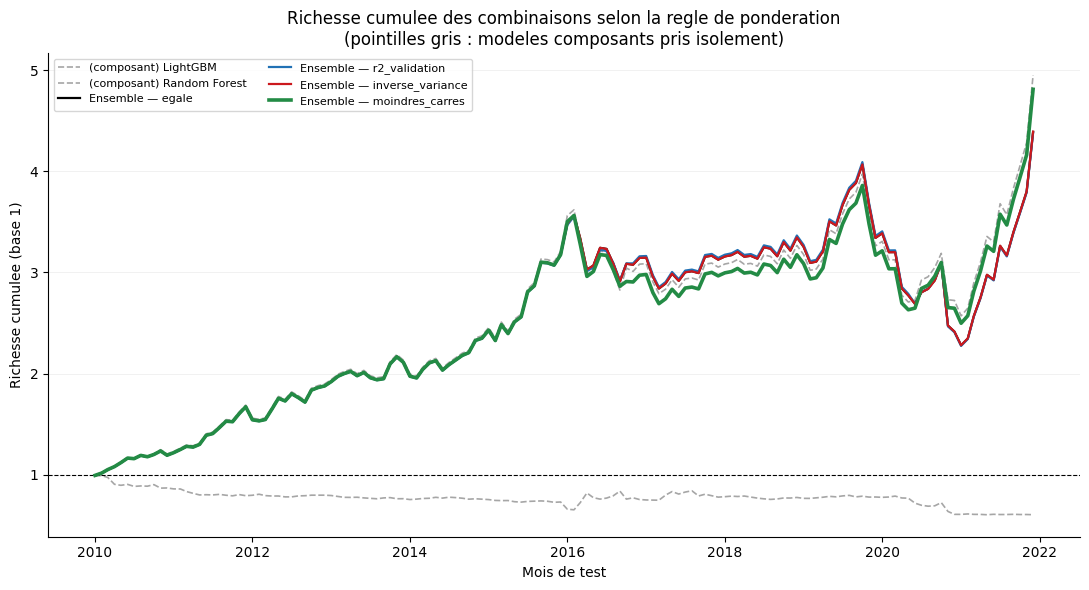

In [32]:
PALETTE_METHODES = ['#000000', '#2171b5', '#cb181d', '#238b45', '#6a51a3']
COULEURS_METHODES = {m: PALETTE_METHODES[i % len(PALETTE_METHODES)]
                     for i, m in enumerate(methodes_ensemble)}

TAILLE_FIGURE = (11, 6)

# ⚠️ La cause des traits parasites : `annee_mois` est une CHAINE ('201001'), donc matplotlib
# la traite comme une categorie et pose un tick par mois. En vraies dates, il choisit tout
# seul des graduations annuelles espacees.
def en_dates(serie):
    return pd.to_datetime(serie.index.astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)

for modele in modeles_ensemble:
    richesse = (1 + rendements_portefeuilles[modele]).cumprod()
    ax.plot(en_dates(richesse), richesse.values, color='0.65', linewidth=1.2,
            linestyle='--', zorder=1, label=f"(composant) {modele}")

for methode in methodes_ensemble:
    richesse = (1 + comparaison_ensembles['rendements'][methode]).cumprod()
    reference = (methode == config.METHODE_PONDERATION_ENSEMBLE)
    ax.plot(en_dates(richesse), richesse.values, label=f"Ensemble — {methode}",
            color=COULEURS_METHODES[methode],
            linewidth=2.6 if reference else 1.6, zorder=5 if reference else 3)

ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Richesse cumulee (base 1)")
ax.set_xlabel("Mois de test")
ax.set_title("Richesse cumulee des combinaisons selon la regle de ponderation\n"
             "(pointilles gris : modeles composants pris isolement)", fontsize=12)
ax.legend(fontsize=8, ncol=2)

# Grille horizontale uniquement, discrete : les verticales n'apportent rien sur une serie
# temporelle et c'est elles qui saturaient la figure.
ax.grid(axis='y', alpha=0.2, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(config.FICHIER_ENSEMBLES_CUMULATIF_PNG, dpi=150)
plt.show()

### C.6 Sauvegarde et enregistrement de l'expérience

Le portefeuille combiné est traité **comme un modèle à part entière** : il obtient sa propre
`cle_experience`, sa ligne au journal des expériences et ses mesures dans l'historique
cumulatif des portefeuilles. Il apparaîtra donc dans les tableaux du notebook 09, à côté des
quatre modèles individuels.

⚠️ Sa clé d'expérience inclut les `cle_experience` des modèles **sources** : combiner un
LightGBM entraîné avec la grille A ou avec la grille B donne deux ensembles différents, donc
deux lignes distinctes — et jamais un doublon si rien n'a changé.

ℹ️ Les colonnes `r2_oos_train` et `r2_oos_validation` du journal valent `NaN` pour cette ligne,
et c'est normal : l'ensemble n'a **pas** de phase d'entraînement propre. Il ne combine que des
prédictions de **test** déjà sauvegardées — sa durée d'entraînement est donc nulle, elle aussi.

In [28]:
METHODE_REFERENCE = config.METHODE_PONDERATION_ENSEMBLE
nom_ensemble = config.NOM_MODELE_ENSEMBLE

# --- Fichiers de SENSIBILITE (les 4 methodes), separes du reste ---
pd.concat(comparaison_ensembles['poids'], names=['methode', 'annee_mois']).to_parquet(
    config.FICHIER_POIDS_ENSEMBLE_METHODES)
comparaison_ensembles['performance'].to_parquet(
    config.FICHIER_PERFORMANCE_ENSEMBLES_METHODES)

# --- Ligne de REFERENCE : une seule methode alimente le journal et le notebook 09 ---
r2_ensemble = float(comparaison_ensembles['r2_oos'][METHODE_REFERENCE])
rendements_portefeuilles[nom_ensemble] = comparaison_ensembles['rendements'][METHODE_REFERENCE]
performance.loc[nom_ensemble] = comparaison_ensembles['performance'].loc[METHODE_REFERENCE]
performance = performance.sort_values('sharpe_ratio', ascending=False)

cles_composantes = [resultats.set_index('modele').loc[m, 'cle_experience']
                    for m in modeles_ensemble]
params_ensemble = ensemble.params_specifiques(modeles_ensemble, cles_composantes)
cle_ensemble_experience = journal.cle_experience_actuelle(nom_ensemble, params_ensemble)
performance.loc[nom_ensemble, 'cle_experience'] = cle_ensemble_experience

predictions['pred_ensemble'] = comparaison_ensembles['predictions_combinees'][METHODE_REFERENCE]
predictions[['permno', 'annee_mois', cible, 'pred_ensemble']].rename(
    columns={'pred_ensemble': 'prediction'}
).to_parquet(config.FICHIER_PREDICTIONS_ENSEMBLE, index=False)

rendements_portefeuilles.to_parquet(config.FICHIER_RENDEMENTS_PORTEFEUILLES)
performance.to_parquet(config.FICHIER_PERFORMANCE_PORTEFEUILLES)

journal.enregistrer_experience(
    modele=nom_ensemble,
    params_specifiques=params_ensemble,
    resultats={
        'n_fenetres': int(resultats['n_fenetres'].max()),
        'r2_oos_train': np.nan,        # l'ensemble n'a pas de phase d'entrainement propre
        'r2_oos_validation': np.nan,
        'r2_oos_test': r2_ensemble,
    },
    duree_entrainement_secondes=0.0,
)
journal.enregistrer_performances_portefeuilles(performance)

Experience ajoutee au journal (cle 7b73c6407897c03c) : Ensemble | modeles=['LightGBM', 'Random Forest'], methode_ponderation=moindres_carres, cles_composantes=['354f633787c432a8', '6465a9b8c2e081b9'], fenetre_ponderation_mois=60, mois_minimum_ponderation=24, poids_positifs=True
Performance de portefeuille ajoutee a l'historique (cle 7b73c6407897c03c) : Ensemble (Sharpe = 0.918)


['7b73c6407897c03c']

**Résumé de la partie C :** prédictions de plusieurs modèles combinées en une seule, avec
des poids fixés à la main ou estimés (toujours sur le **passé** uniquement), puis traduites en
portefeuille long-short évalué comme les autres. Poids sauvegardés dans
`outputs/poids_ensemble_par_mois.parquet`, prédictions combinées dans
`outputs/predictions_ensemble.parquet`.

**Pour explorer**, dans `config.py` : change `MODELES_ENSEMBLE` (quels modèles),
`METHODE_PONDERATION_ENSEMBLE` (comment les pondérer), `FENETRE_PONDERATION_ENSEMBLE_MOIS`
(sur quelle profondeur d'historique), puis ré-exécute ce notebook — chaque configuration
devient une expérience distincte au notebook 09, sans écraser les précédentes.

⚠️ **Limites propres à cette partie**, en plus de celles de la partie B :
- Les poids sont estimés sur des **mois de test passés**. Réaliste (aucune information future
  n'est utilisée), mais ça suppose implicitement qu'on aurait, à l'époque, déjà disposé des
  quatre modèles entraînés — la combinaison est donc réalisable *au sein de ce protocole*,
  pas forcément « en temps réel » au sens strict.
- Combiner des modèles entraînés sur les **mêmes** données et les **mêmes** prédicteurs limite
  mécaniquement la diversification atteignable (voir les corrélations d'erreurs en C.3).
- Multiplier les configurations d'ensemble jusqu'à en trouver une qui bat tout le monde est
  une forme de *data snooping* : le notebook 09 garde la trace de **toutes** celles testées,
  précisément pour que ce nombre reste visible.

## Synthèse finale — précision statistique vs valeur économique

Les parties A et B évaluent les 4 modèles (et la partie C leur combinaison) sous deux angles différents : le `R²_oos` mesure
une précision statistique **par observation**, tandis que le ratio de Sharpe du portefeuille
long-short mesure une performance **économique agrégée**, une fois les prédictions traduites
en décisions d'achat/vente. Rien ne garantit *a priori* que les deux classements coïncident :
un modèle peut avoir un `R²_oos` très légèrement supérieur tout en se trompant plus souvent sur
les cas qui comptent le moins pour un portefeuille (le milieu du classement, les déciles 4 à 7),
et un peu moins souvent sur les extrêmes (déciles 1 et 10) qui sont les seuls à peser dans un
portefeuille long-short — c'est exactement le genre de nuance qu'un `R²_oos` global ne peut
pas capturer.

In [29]:
# Le portefeuille combine (partie C) est inclus : son R2_oos test a ete calcule en C.4 sur
# exactement les memes lignes que les modeles individuels.
r2_par_modele = resultats.set_index('modele')['r2_oos_test'].to_dict()
r2_par_modele[config.NOM_MODELE_ENSEMBLE] = r2_ensemble

synthese = pd.DataFrame({
    'r2_oos_test': pd.Series(r2_par_modele),
    'sharpe_ratio': performance['sharpe_ratio'],
}).dropna(subset=['sharpe_ratio'])

synthese['rang_r2_oos'] = synthese['r2_oos_test'].rank(ascending=False).astype(int)
synthese['rang_sharpe'] = synthese['sharpe_ratio'].rank(ascending=False).astype(int)
synthese = synthese.sort_values('rang_r2_oos')

print("Classement selon les deux angles d'evaluation (1 = meilleur), ensemble inclus :")
synthese.round(4)

Classement selon les deux angles d'evaluation (1 = meilleur), ensemble inclus :


,r2_oos_test,sharpe_ratio,rang_r2_oos,rang_sharpe
Random Forest,0.0048,0.9175,1,3
Elastic Net,0.0033,-0.1693,2,4
Ensemble,0.0018,0.9179,3,2
LightGBM,-0.0106,-0.3912,4,5
Regression lineaire,-0.2432,1.0553,5,1


In [30]:
classements_identiques = (synthese['rang_r2_oos'] == synthese['rang_sharpe']).all()

if classements_identiques:
    print("Les deux classements coincident parfaitement : le modele le plus precis")
    print("statistiquement est aussi celui qui degage le meilleur portefeuille ici.")
else:
    print("Les deux classements NE coincident PAS parfaitement :")
    for modele in synthese.index:
        r2, sh = synthese.loc[modele, 'rang_r2_oos'], synthese.loc[modele, 'rang_sharpe']
        if r2 != sh:
            print(f"  - {modele:22s} : rang {r2} en R2_oos, mais rang {sh} en Sharpe")
    print()
    print("Ce n'est pas anormal avec aussi peu de modeles (l'ecart peut venir du bruit")
    print("d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi")
    print("il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :")
    print("la performance economique realisee (deciles extremes, cout du risque...) peut")
    print("reordonner les modeles differemment de la precision statistique globale.")

Les deux classements NE coincident PAS parfaitement :
  - Random Forest          : rang 1 en R2_oos, mais rang 3 en Sharpe
  - Elastic Net            : rang 2 en R2_oos, mais rang 4 en Sharpe
  - Ensemble               : rang 3 en R2_oos, mais rang 2 en Sharpe
  - LightGBM               : rang 4 en R2_oos, mais rang 5 en Sharpe
  - Regression lineaire    : rang 5 en R2_oos, mais rang 1 en Sharpe

Ce n'est pas anormal avec aussi peu de modeles (l'ecart peut venir du bruit
d'echantillonnage sur une seule periode de test), mais ca illustre bien pourquoi
il ne faut jamais choisir un modele sur la seule base du R2_oos en finance :
la performance economique realisee (deciles extremes, cout du risque...) peut
reordonner les modeles differemment de la precision statistique globale.


⚠️ **Prudence sur cette synthèse** : avec aussi peu de modèles, un calcul de corrélation
de rang formel (Spearman) n'aurait pas vraiment de sens statistique — c'est pourquoi on se
contente ici d'une comparaison qualitative des deux classements. Sur un projet avec davantage
de modèles ou de sous-périodes de test, ce même exercice (croiser précision statistique et
performance économique réalisée) devient un diagnostic bien plus robuste.

## Résumé global

- **Partie A** : 4 modèles comparés sur `R²_oos` (train/validation/test, pooled sur toutes
  les fenêtres de chacun), avec diagnostic de sur-apprentissage via l'écart train/test, et
  évolution du R²_oos test fenêtre par fenêtre.
- **Partie B** : les mêmes 4 modèles traduits en portefeuilles long-short par décile
  (équipondérés, sur l'ensemble des prédictions de test déjà sauvegardées), évalués avec des
  mesures financières standard (Sharpe, Sortino, drawdown maximum, significativité
  statistique, monotonie par décile).
- **Partie C** : portefeuille **combiné** à partir des prédictions de plusieurs modèles
  (`config.MODELES_ENSEMBLE`), avec des poids fixes ou ré-estimés chaque mois sur le passé
  seulement — évalué exactement comme les autres, et enregistré comme une expérience à part
  entière (visible au notebook 09).
- **Synthèse** : classements `R²_oos` et Sharpe comparés côte à côte — un rappel qu'un modèle
  statistiquement plus précis n'est pas automatiquement celui qui produit la meilleure
  stratégie d'investissement.
- Tous les résultats de ce notebook sont sauvegardés dans `outputs/` : comparaison des R²_oos,
  rendements mensuels et mesures de performance des portefeuilles.
